# Lab 2

Dynamic Programming Methods

Task: Implement policy iteration and value iteration to solve GridWorld. Create a custom GridWorld environment (4×4 or larger) following Gymnasium’s API with configurable rewards, obstacles, and transition dynamics (including stochastic transitions). Code both synchronous and in-place versions of each algorithm using NumPy arrays for value functions V(s) and policies π(s). Since DP requires the full transition model P(s’,r|s,a), implement a method to extract or define these probabilities.

Create visualizations showing: (1) the value function at each iteration as a heatmap using Matplotlib, (2) the policy at each iteration using arrows (quiver plots), and (3) convergence curves comparing number of iterations and wall-clock time. Test on at least two GridWorld configurations: one deterministic and one stochastic (e.g., 80% intended direction, 10% perpendicular). Apply your DP implementations to Gymnasium’s FrozenLake-v1 by accessing its transition dynamics. Document which algorithm converges faster under different conditions and explain why.



## Creating the Custom GridWorld Environment that follows the Gymnasium API Structure

In [2]:
# Loading numpy for algorithm
import numpy as np

# GridWorld Environment
class GridWorldEnv:
    def __init__(self, size=4, start=(0,0), goal=(3,3),
                 obstacles=None, step_reward=-1.0, goal_reward=10.0,
                 stochastic=False, p_intended=0.8):

        self.size = size
        self.nS = size * size
        self.nA = 4  # up, right, down, left

        self.start = start
        self.goal = goal
        self.obstacles = obstacles if obstacles else []

        # Setting up Rewards
        self.step_reward = step_reward
        self.goal_reward = goal_reward

        self.stochastic = stochastic
        self.p_intended = p_intended

        self.actions = {
            0: (-1, 0),  # up action
            1: (0, 1),   # right action
            2: (1, 0),   # down action
            3: (0, -1)   # left action
        }

        self.P = self._build_transition_model()

    def state_to_pos(self, s):
        return (s // self.size, s % self.size)

    def pos_to_state(self, pos):
        return pos[0] * self.size + pos[1]

    def _step(self, state, action):
        r, c = self.state_to_pos(state)
        dr, dc = self.actions[action]
        nr, nc = r + dr, c + dc

        if not (0 <= nr < self.size and 0 <= nc < self.size):
            nr, nc = r, c

        if (nr, nc) in self.obstacles:
            nr, nc = r, c

        next_state = self.pos_to_state((nr, nc))

        if (nr, nc) == self.goal:
            return next_state, self.goal_reward, True
        else:
            return next_state, self.step_reward, False

    # Setting up dynamic transition
    def _build_transition_model(self):
        P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}

        for s in range(self.nS):
            pos = self.state_to_pos(s)

            for a in range(self.nA):
                if self.stochastic:
                    probs = [(a, self.p_intended),
                             ((a+1)%4, (1-self.p_intended)/2),
                             ((a-1)%4, (1-self.p_intended)/2)]
                else:
                    probs = [(a, 1.0)]

                transitions = []
                for a2, p in probs:
                    ns, r, done = self._step(s, a2)
                    transitions.append((p, ns, r, done))

                P[s][a] = transitions

        return P


## Setting up Value Iteration for both Synchronous and In-place


In [3]:
def value_iteration(env, gamma=0.99, theta=1e-6, in_place=False):
    V = np.zeros(env.nS) # Initializing V
    history = []

    while True:
        delta = 0
        V_new = V.copy() if not in_place else V

        for s in range(env.nS):
            q_values = []
            for a in range(env.nA):
                q = sum(p * (r + gamma * V[ns])
                        for p, ns, r, done in env.P[s][a])
                q_values.append(q)

            best = max(q_values)

            if in_place:
                delta = max(delta, abs(best - V[s]))
                V[s] = best
            else:
                delta = max(delta, abs(best - V[s]))
                V_new[s] = best

        if not in_place:
            V = V_new

        history.append(V.copy())

        if delta < theta:
            break

    policy = np.zeros(env.nS, dtype=int) # Setting up Policy
    for s in range(env.nS):
        q_values = []
        for a in range(env.nA):
            q = sum(p * (r + gamma * V[ns])
                    for p, ns, r, done in env.P[s][a])
            q_values.append(q)
        policy[s] = np.argmax(q_values)

    return V, policy, history


## Setting up Policy Iteration for both Synchronous and In-place

In [4]:
def policy_iteration(env, gamma=0.99, theta=1e-6, in_place=False):
    policy = np.random.randint(env.nA, size=env.nS)
    V = np.zeros(env.nS)
    history = []

    while True:
        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy() if not in_place else V

            for s in range(env.nS):
                a = policy[s]
                v = sum(p * (r + gamma * V[ns])
                        for p, ns, r, done in env.P[s][a])

                if in_place:
                    delta = max(delta, abs(v - V[s]))
                    V[s] = v
                else:
                    delta = max(delta, abs(v - V[s]))
                    V_new[s] = v

            if not in_place:
                V = V_new

            if delta < theta:
                break

        # Policy Improvement
        stable = True
        for s in range(env.nS):
            old_a = policy[s]

            q_values = []
            for a in range(env.nA):
                q = sum(p * (r + gamma * V[ns])
                        for p, ns, r, done in env.P[s][a])
                q_values.append(q)

            policy[s] = np.argmax(q_values)

            if old_a != policy[s]:
                stable = False

        history.append(V.copy())

        if stable:
            break

    return V, policy, history


## Visualization Functions

In [23]:
import matplotlib.pyplot as plt

# Heatmap

def plot_value(V, size, title="Value Function"):
    grid = V.reshape(size, size)

    plt.imshow(grid, cmap="Blues")
    plt.colorbar()

    # Add values inside cells
    for i in range(size):
        for j in range(size):
            plt.text(j, i, f"{grid[i, j]:.1f}",
                     ha='center', va='center', color='black')

    plt.title(title)
    plt.xticks(range(size))
    plt.yticks(range(size))
    plt.gca().invert_yaxis()
    plt.show()

# Policy Arrows

def plot_policy(policy, V, size, title="Policy"):
    arrows = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}

    grid = V.reshape(size, size)

    plt.imshow(grid, cmap="Blues")
    plt.colorbar()

    X, Y = np.meshgrid(np.arange(size), np.arange(size))
    U = np.zeros_like(X, dtype=float)
    Vv = np.zeros_like(Y, dtype=float)

    for s in range(size*size):
        r, c = s // size, s % size
        dr, dc = arrows[policy[s]]
        U[r, c] = dc
        Vv[r, c] = -dr

    plt.quiver(X, Y, U, Vv, color='black')

    # Optional: show values too
    for i in range(size):
        for j in range(size):
            plt.text(j, i, f"{grid[i, j]:.1f}",
                     ha='center', va='center', color='black', fontsize=8)

    plt.title(title)
    plt.xticks(range(size))
    plt.yticks(range(size))
    plt.gca().invert_yaxis()
    plt.show()


# Convergence Curve

import time

def run_with_timing(func, env):
    start = time.time()
    V, pi, hist = func(env)
    end = time.time()
    return len(hist), end - start

## Experiments

### Deterministic Grid Experiemnts

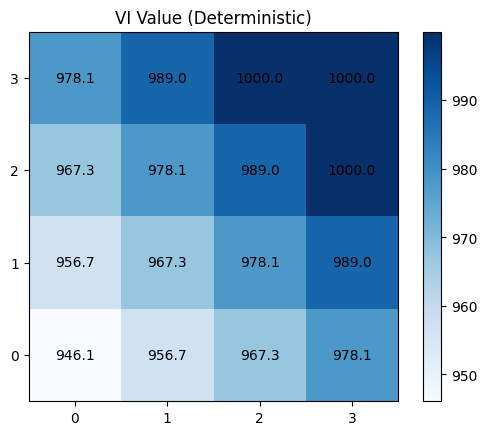

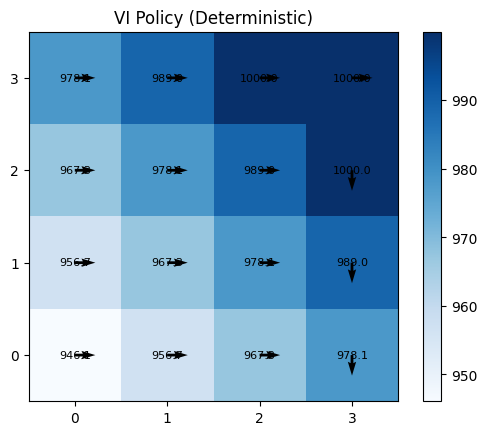

In [24]:
env_det = GridWorldEnv(size=4, stochastic=False)

V_vi, pi_vi, hist_vi = value_iteration(env_det)
V_pi, pi_pi, hist_pi = policy_iteration(env_det)

plot_value(V_vi, 4, "VI Value (Deterministic)")
plot_policy(pi_vi, V_vi, 4, "VI Policy (Deterministic)")

### Stochastic Grid Experiment

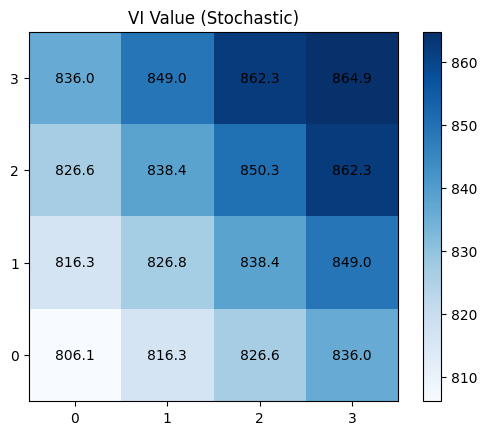

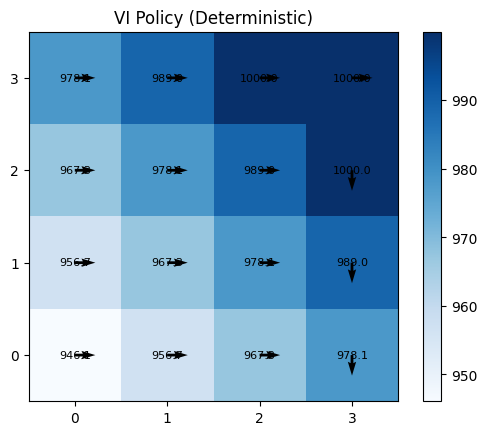

In [25]:
env_stoch = GridWorldEnv(size=4, stochastic=True, p_intended=0.8)

V_vi_s, pi_vi_s, _ = value_iteration(env_stoch)
V_pi_s, pi_pi_s, _ = policy_iteration(env_stoch)

plot_value(V_vi_s, 4, "VI Value (Stochastic)")
plot_policy(pi_vi, V_vi, 4, "VI Policy (Deterministic)")

## Transition: FrozenLake Transition Extraction

In [26]:
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=True)
P = env.unwrapped.P

class FrozenLakeWrapper:
    def __init__(self, P):
        self.P = P
        self.nS = len(P)
        self.nA = len(P[0])

env_fl = FrozenLakeWrapper(P)

V_fl, pi_fl, _ = value_iteration(env_fl)

## Comparisons

In [27]:
for env in [env_det, env_stoch]:
    vi_iter, vi_time = run_with_timing(value_iteration, env)
    pi_iter, pi_time = run_with_timing(policy_iteration, env)

    print("Env:", "Stochastic" if env.stochastic else "Deterministic")
    print(f"VI: {vi_iter} iterations, {vi_time:.4f}s")
    print(f"PI: {pi_iter} iterations, {pi_time:.4f}s\n")

Env: Deterministic
VI: 1605 iterations, 0.1237s
PI: 7 iterations, 0.0418s

Env: Stochastic
VI: 1591 iterations, 0.2201s
PI: 4 iterations, 0.1701s

